In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression



import importlib
import bootstrap
import cifar10_patch_analysis
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)
importlib.reload(cifar10_patch_analysis)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
from cifar10_patch_analysis import (
    load_bootstrap_runs, fit_patch_distributions,
    plot_image_explanation, plot_patch_importance_summary,
)
print("Modules reloaded successfully!")

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modules reloaded successfully!


In [2]:
run0 = np.load("shap_results/bootstrap_runs_vit_base/run_000/shap_results/patch_shap.npy", allow_pickle=True)

In [3]:
run0.shape

(100, 24, 24)

In [4]:
run_root = "shap_results/bootstrap_runs_vit_base"
run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)

cifar_boot_results = []

for run_name in run_dirs:
    run_idx = int(run_name.split("_")[-1])
    patch_shap = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy"),
        allow_pickle=True,
    )

    if patch_shap.ndim != 3:
        raise ValueError(f"Expected patch_shap to have shape (n_images, n_rows, n_cols), got {patch_shap.shape}")

    abs_shap = np.abs(patch_shap)
    sum_abs_shap = abs_shap.sum(axis=0)
    mean_abs_shap = abs_shap.mean(axis=0)
    n_images, n_rows, n_cols = patch_shap.shape

    rows = []
    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            rows.append({
                "feature": f"r{row_idx}c{col_idx}",
                "bootstrap_id": run_idx,
                "perm_round": 0,
                "sum_abs_shap": float(sum_abs_shap[row_idx, col_idx]),
                "mean_abs_shap": float(mean_abs_shap[row_idx, col_idx]),
                "n_samples": int(n_images),
            })

    cifar_boot_results.append(pd.DataFrame(rows))

print(f"Loaded {len(cifar_boot_results)} runs")
print(cifar_boot_results[0].head())

Loaded 50 runs
  feature  bootstrap_id  perm_round  sum_abs_shap  mean_abs_shap  n_samples
0    r0c0             0           0      0.000145       0.000001        100
1    r0c1             0           0      0.000143       0.000001        100
2    r0c2             0           0      0.000141       0.000001        100
3    r0c3             0           0      0.000148       0.000001        100
4    r0c4             0           0      0.000144       0.000001        100


In [5]:
boot_results, images, labels, predicted = load_bootstrap_runs()
dist_df = fit_patch_distributions(boot_results)

Auto bandwidth (Scott's rule, n=50): 2.008e-06
Fitted distributions: 57600 (sample_id, patch) pairs


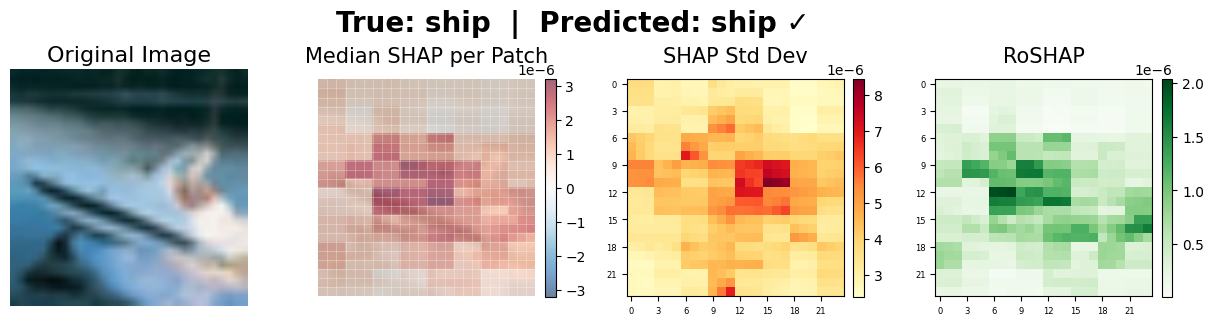

In [6]:
fig = plot_image_explanation(94, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

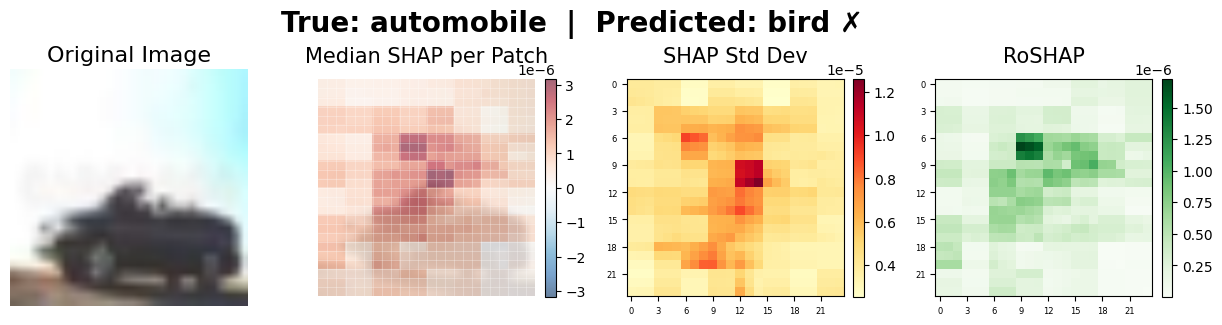

In [7]:
fig = plot_image_explanation(73, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

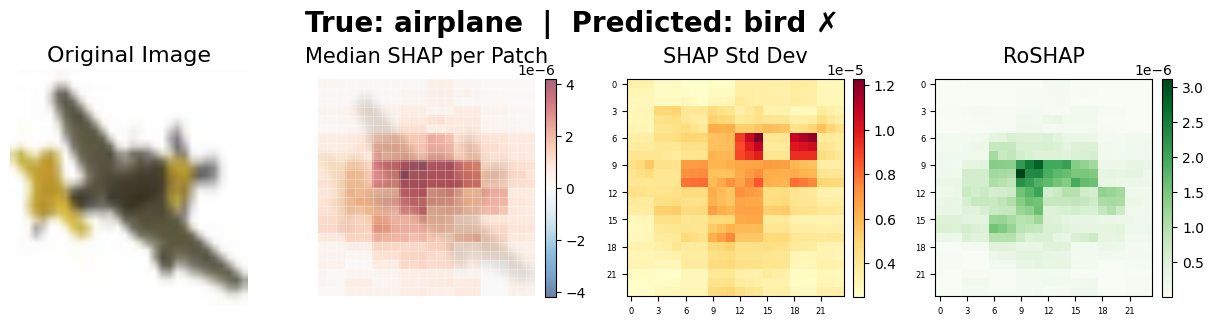

In [8]:
fig = plot_image_explanation(8, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

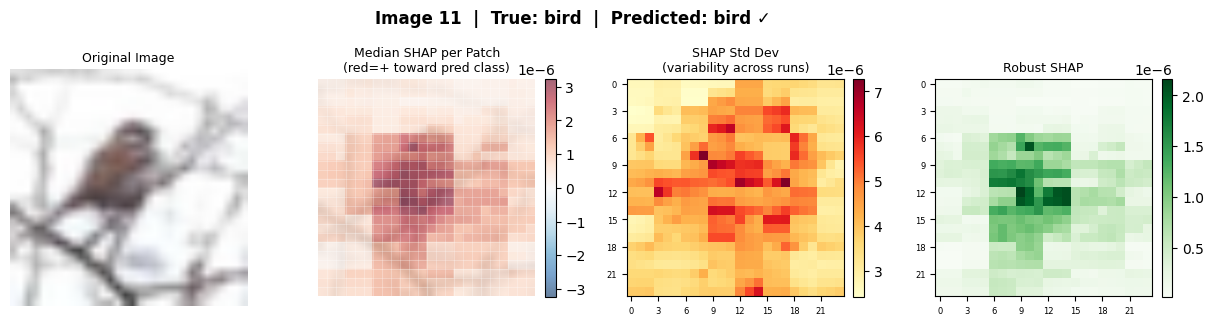

In [7]:
fig = plot_image_explanation(11, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

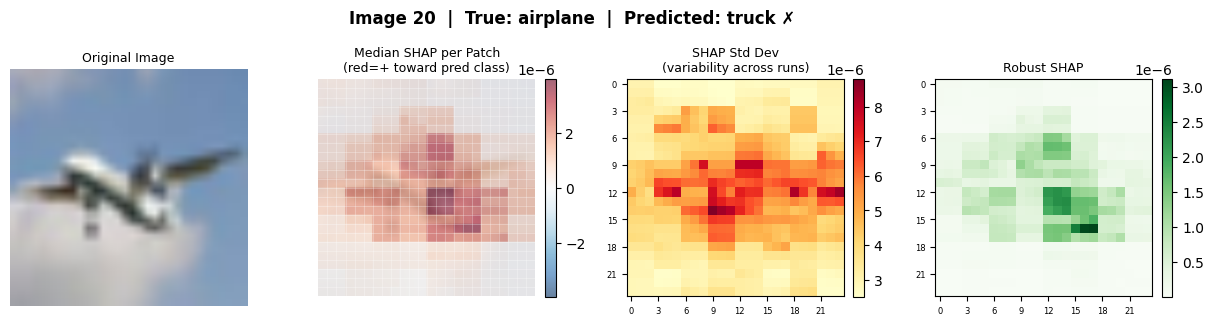

In [8]:
fig = plot_image_explanation(20, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

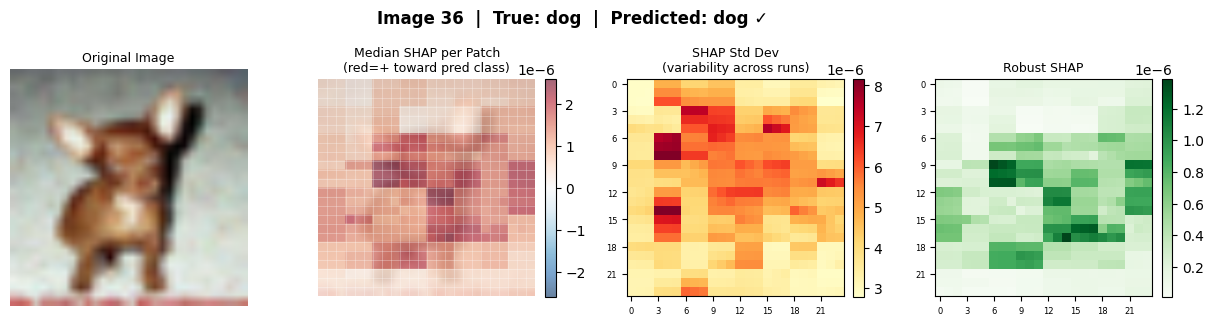

In [9]:
fig = plot_image_explanation(36, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

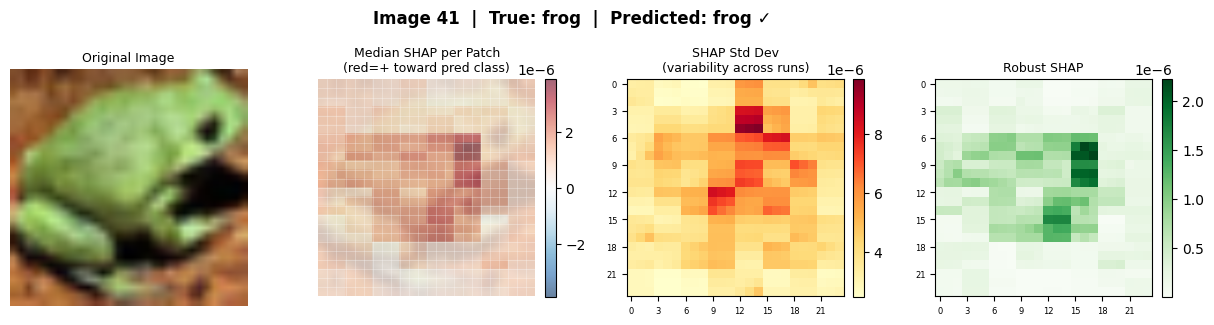

In [11]:
fig = plot_image_explanation(41, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

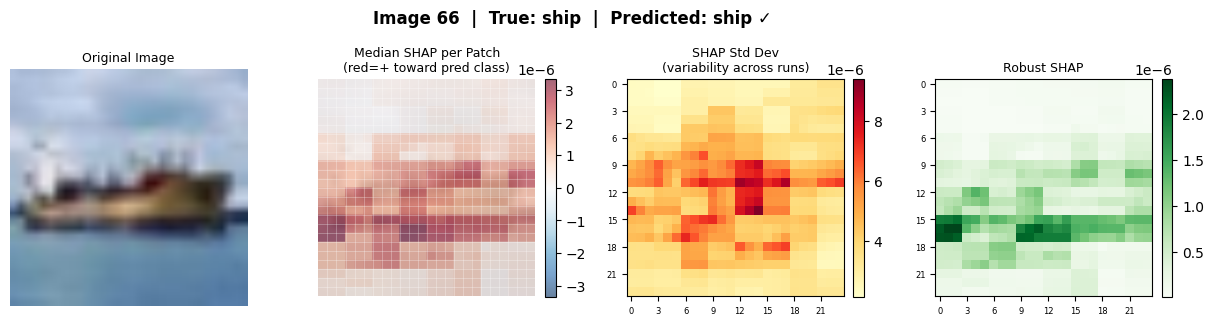

In [12]:
fig = plot_image_explanation(66, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

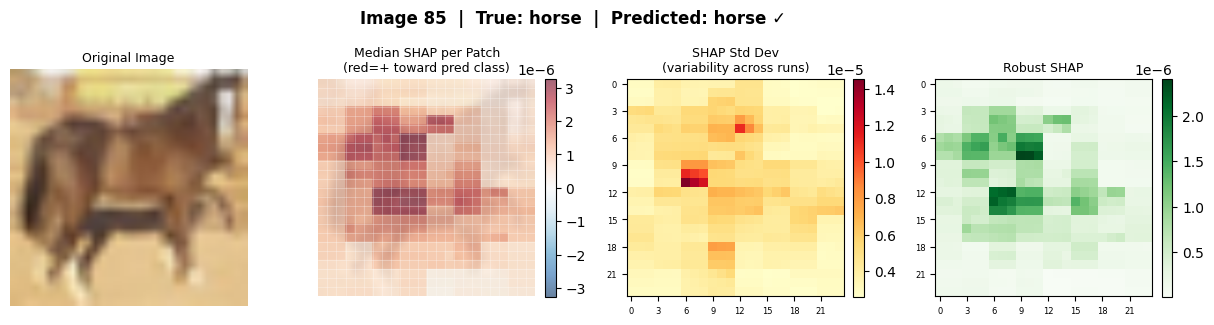

In [13]:
fig = plot_image_explanation(85, dist_df, images, labels, predicted, figsize=(15, 3.5))
plt.show()

In [86]:
# fig = plot_image_explanation(33, dist_df, images, labels, predicted)
# plt.show()

In [18]:
# for i in range(60,80):
#     fig = plot_image_explanation(i, dist_df, images, labels, predicted, figsize=(15, 3.5))
#     plt.show()

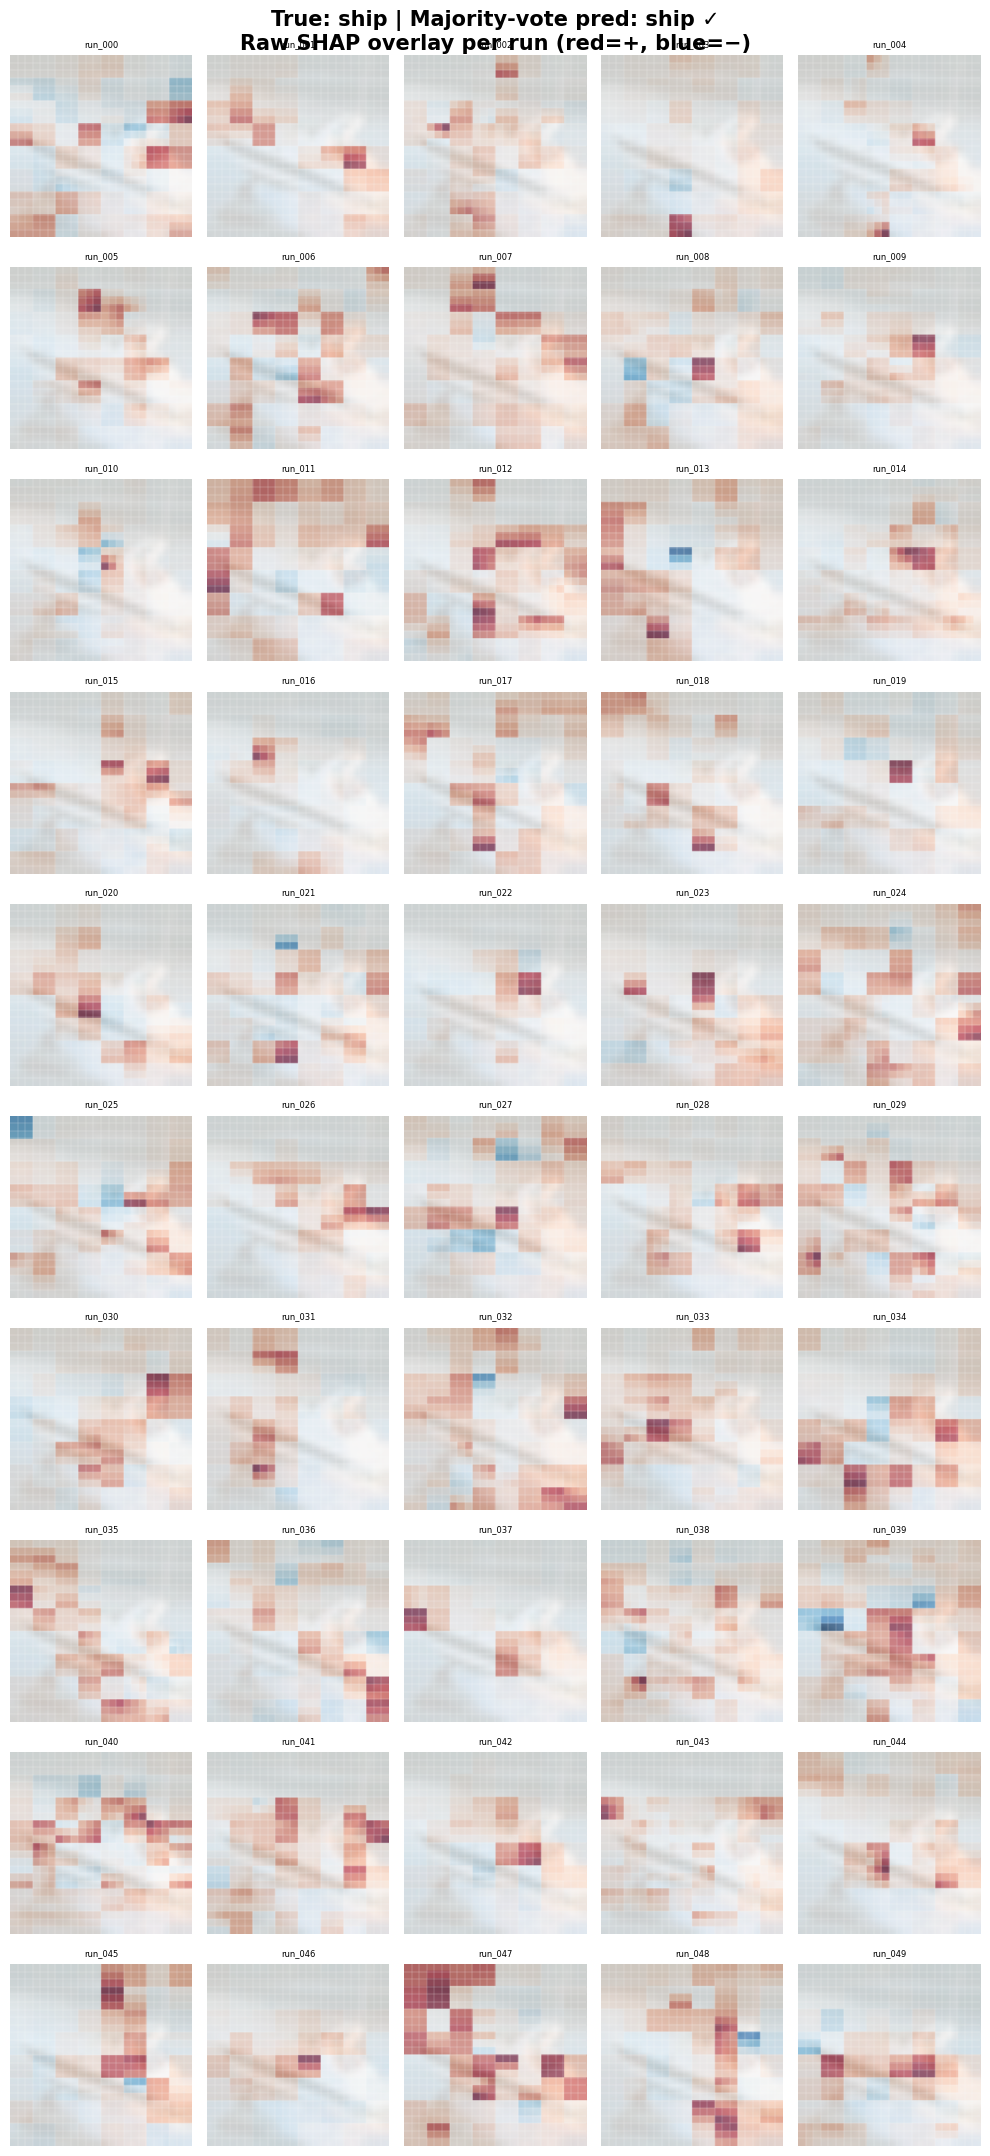

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

image_idx = 94  # ← change this to your selected image

run_root = "shap_results/bootstrap_runs_vit_base"
run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

img = images[image_idx]
img_h, img_w = img.shape[:2]
true_cls = CIFAR10_CLASSES[labels[image_idx]]
pred_cls = CIFAR10_CLASSES[predicted[image_idx]]
match = "✓" if labels[image_idx] == predicted[image_idx] else "✗"

n_cols = 5
n_rows = (len(run_dirs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.2))
axes = axes.ravel()

fig.suptitle(
    # f"Image {image_idx} — True: {true_cls} | Majority-vote pred: {pred_cls} {match}\n"
    f"True: {true_cls} | Majority-vote pred: {pred_cls} {match}\n"
    f"Raw SHAP overlay per run (red=+, blue=−)",
    fontsize=15, fontweight="bold",
)

for i, run_name in enumerate(run_dirs):
    shap_all = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy")
    )  # (100, 24, 24)
    shap_map = shap_all[image_idx]  # (24, 24)
    n_ph, n_pw = shap_map.shape

    # upsample patch map to image size via nearest-neighbour (integer scale)
    scale_h = img_h // n_ph
    scale_w = img_w // n_pw
    if scale_h >= 1 and scale_w >= 1:
        shap_up = np.kron(shap_map, np.ones((scale_h, scale_w)))
    else:
        shap_up = shap_map  # patch grid already at or larger than image

    vabs = max(np.abs(shap_map).max(), 1e-12)
    norm = TwoSlopeNorm(vcenter=0, vmin=-vabs, vmax=vabs)

    ax = axes[i]
    ax.imshow(img, alpha=0.45)
    ax.imshow(shap_up, cmap="RdBu_r", norm=norm, alpha=0.6)
    step_h = img_h / n_ph
    step_w = img_w / n_pw
    for k in range(1, n_ph):
        ax.axhline(k * step_h - 0.5, color="white", lw=0.3, alpha=0.5)
        ax.axvline(k * step_w - 0.5, color="white", lw=0.3, alpha=0.5)
    ax.set_title(run_name, fontsize=6)
    ax.axis("off")

for j in range(len(run_dirs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

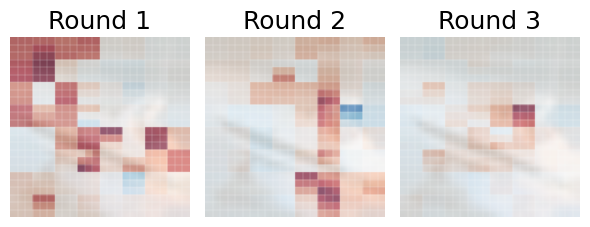

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
seed = 2

image_idx = 94  # ← change this to your selected image
n_sample = 3   # ← how many random runs to show

run_root = "shap_results/bootstrap_runs_vit_base"
all_run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)
rng = np.random.default_rng(seed)
# run_dirs = sorted(rng.choice(all_run_dirs, size=min(n_sample, len(all_run_dirs)), replace=False).tolist())
run_dirs = ['run_047', 'run_048', 'run_009']


CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

img = images[image_idx]
img_h, img_w = img.shape[:2]
true_cls = CIFAR10_CLASSES[labels[image_idx]]
pred_cls = CIFAR10_CLASSES[predicted[image_idx]]
match = "✓" if labels[image_idx] == predicted[image_idx] else "✗"

n_cols = 3
n_rows = (len(run_dirs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
axes = axes.ravel()

# fig.suptitle(
#     f"True: {true_cls} | Majority-vote pred: {pred_cls} {match}\n"
#     f"Raw SHAP overlay — {n_sample} random runs (red=+, blue=−)",
#     fontsize=12, fontweight="bold",
# )

for i, run_name in enumerate(run_dirs):
    shap_all = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy")
    )  # (100, 24, 24)
    shap_map = shap_all[image_idx]  # (24, 24)
    n_ph, n_pw = shap_map.shape

    scale_h = img_h // n_ph
    scale_w = img_w // n_pw
    shap_up = np.kron(shap_map, np.ones((scale_h, scale_w))) if scale_h >= 1 and scale_w >= 1 else shap_map

    vabs = max(np.abs(shap_map).max(), 1e-12)
    norm = TwoSlopeNorm(vcenter=0, vmin=-vabs, vmax=vabs)

    ax = axes[i]
    ax.imshow(img, alpha=0.45)
    ax.imshow(shap_up, cmap="RdBu_r", norm=norm, alpha=0.6)
    step_h = img_h / n_ph
    step_w = img_w / n_pw
    for k in range(1, n_ph):
        ax.axhline(k * step_h - 0.5, color="white", lw=0.3, alpha=0.5)
        ax.axvline(k * step_w - 0.5, color="white", lw=0.3, alpha=0.5)
    ax.set_title(f"Round {i + 1}", fontsize=18)
    ax.axis("off")

for j in range(len(run_dirs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()